# QC: NEWBEE Orientation Transformation Verification

This notebook validates the coordinate-frame transformation applied to NEWBEE sensor data.

**Target convention (static standing pose):**

| | X | Y | Z |
|---|---|---|---|
| **Non-foot** | forward | **up** | right |
| **Foot** | **up** | backward | right |

**Verification steps:**
1. **Engineering Verification** — Signal integrity
   - 1a. Magnitude invariance: $\|\mathbf{v}_{\text{pre}}\| = \|\mathbf{v}_{\text{post}}\|$
   - 1b. Orthonormality: $R^\top R = I$, $\det(R) = 1$
2. **Scientific Verification** — Physical & biomechanical plausibility
   - 2a. Gravity alignment during static phase
   - 2b. PCA of angular velocity during gait

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve().parent))
from sync_columns.config import RAW_DIR, SYNCED_DIR, COORDS_SYNCED_DIR, SENSOR_TYPES
from sync_columns.transform_orientation import (
    NEWBEE_RAW_XSENS, NEWBEE_SYNCED, NEWBEE_COORDS,
    SEGMENT_TO_XSENS, FOOT_SEGMENTS,
    load_quaternions, find_static_window, mean_quaternion,
    derive_forward_from_pelvis, compute_correction_with_heading,
    quat_cols,
)

AXES = ["X", "Y", "Z"]
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5)})

In [2]:
EXAMPLE_REL = "courseA/id01/xsens.csv"

pre_path  = os.path.join(NEWBEE_SYNCED, EXAMPLE_REL)
post_path = os.path.join(NEWBEE_COORDS, EXAMPLE_REL)
raw_path  = os.path.join(NEWBEE_RAW_XSENS, EXAMPLE_REL)

pre_df  = pd.read_csv(pre_path)
post_df = pd.read_csv(post_path)
raw_df  = pd.read_csv(raw_path)

print(f"Pre-rotation  (01_columns_synced): {pre_df.shape}")
print(f"Post-rotation (02_coords_synced):  {post_df.shape}")
print(f"Raw Xsens data:                    {raw_df.shape}")
print(f"\nSynced columns (first 9): {list(pre_df.columns[:9])}")

Pre-rotation  (01_columns_synced): (41480, 135)
Post-rotation (02_coords_synced):  (41480, 135)
Raw Xsens data:                    (41480, 757)

Synced columns (first 9): ['PELVIS_GYR_X', 'PELVIS_GYR_Y', 'PELVIS_GYR_Z', 'TRUNK_GYR_X', 'TRUNK_GYR_Y', 'TRUNK_GYR_Z', 'HEAD_GYR_X', 'HEAD_GYR_Y', 'HEAD_GYR_Z']


In [3]:
heading_fwd = derive_forward_from_pelvis(raw_df)

corrections = {}
for seg, xsens_seg in SEGMENT_TO_XSENS.items():
    qcols = quat_cols(xsens_seg)
    if not all(c in raw_df.columns for c in qcols):
        continue
    rots = load_quaternions(raw_df, xsens_seg)
    start, end = find_static_window(raw_df, xsens_seg)
    R_mean = mean_quaternion(rots[start:end])
    R_corr = compute_correction_with_heading(R_mean, seg, heading_fwd)
    corrections[seg] = {
        "R_corr": R_corr,
        "R_mean": R_mean,
        "rots": rots,
        "static_window": (start, end),
        "xsens_seg": xsens_seg,
    }

print(f"Correction rotations computed for {len(corrections)} segments:")
for seg, info in corrections.items():
    sw = info["static_window"]
    det = np.linalg.det(info["R_corr"].as_matrix())
    print(f"  {seg:12s}  static=[{sw[0]:5d}, {sw[1]:5d}]  det={det:.6f}")

Correction rotations computed for 15 segments:
  PELVIS        static=[41414, 41474]  det=1.000000
  TRUNK         static=[ 7421,  7481]  det=1.000000
  HEAD          static=[21021, 21081]  det=1.000000
  R_ARM         static=[41419, 41479]  det=1.000000
  L_ARM         static=[ 7423,  7483]  det=1.000000
  R_FOREARM     static=[41403, 41463]  det=1.000000
  L_FOREARM     static=[ 7344,  7404]  det=1.000000
  R_HAND        static=[41403, 41463]  det=1.000000
  L_HAND        static=[ 7345,  7405]  det=1.000000
  R_THIGH       static=[ 7654,  7714]  det=1.000000
  L_THIGH       static=[ 7686,  7746]  det=1.000000
  R_SHANK       static=[41419, 41479]  det=1.000000
  L_SHANK       static=[41407, 41467]  det=1.000000
  R_FOOT        static=[ 7342,  7402]  det=1.000000
  L_FOOT        static=[41402, 41462]  det=1.000000


---
## 1. Engineering Verification: Signal Integrity

Rotation matrices change the **direction** of vectors but must **never** change their magnitude.
If any magnitude changes, the rotation matrix is not a proper rotation.

### 1a. Magnitude Invariance Check

For every sensor channel (ACC, GYR, MAG) and every segment, the Euclidean norm of each sample
must be identical before and after rotation:

$$\|\mathbf{v}_{\text{pre}}\|_2 = \|\mathbf{v}_{\text{post}}\|_2 \quad \forall \text{ samples}$$

In [4]:
mag_results = []
for seg in corrections:
    for stype in SENSOR_TYPES:
        cols = [f"{seg}_{stype}_{ax}" for ax in AXES]
        if not all(c in pre_df.columns for c in cols):
            continue
        norm_pre  = np.linalg.norm(pre_df[cols].values, axis=1)
        norm_post = np.linalg.norm(post_df[cols].values, axis=1)
        abs_err = np.abs(norm_pre - norm_post)
        rel_err = abs_err / (norm_pre + 1e-12)
        mag_results.append({
            "segment": seg, "sensor": stype,
            "max_abs_err": abs_err.max(),
            "mean_abs_err": abs_err.mean(),
            "max_rel_err": rel_err.max(),
            "mean_rel_err": rel_err.mean(),
        })

mag_df = pd.DataFrame(mag_results)
print("=== Magnitude Invariance Summary ===")
print(f"  Max absolute error across all channels: {mag_df['max_abs_err'].max():.2e}")
print(f"  Max relative error across all channels: {mag_df['max_rel_err'].max():.2e}")
print(f"  PASS: {mag_df['max_rel_err'].max() < 1e-6}")
print()
mag_df

=== Magnitude Invariance Summary ===
  Max absolute error across all channels: 8.53e-14
  Max relative error across all channels: 3.69e-14
  PASS: True



,segment,sensor,max_abs_err,mean_abs_err,max_rel_err,mean_rel_err
0,PELVIS,ACC,7.105427e-15,7.222328e-16,1.370124e-15,1.630974e-16
1,PELVIS,GYR,3.108624e-15,2.543726e-16,8.340145e-15,3.068681e-16
2,PELVIS,MAG,8.881784e-16,9.956409e-17,8.266448e-16,1.037974e-16
3,TRUNK,ACC,3.552714e-15,3.229175e-16,1.247967e-15,8.954745e-17
4,TRUNK,GYR,1.776357e-15,1.434031e-16,3.692260e-14,2.873131e-16
5,TRUNK,MAG,6.661338e-16,8.823436e-17,7.300169e-16,9.028465e-17
6,HEAD,ACC,8.881784e-15,5.319622e-16,1.797726e-15,1.507821e-16
7,HEAD,GYR,2.664535e-15,1.250529e-16,1.490701e-14,3.703698e-16
8,HEAD,MAG,8.881784e-16,1.465237e-16,8.082287e-16,1.497723e-16
9,R_ARM,ACC,5.329071e-15,3.650353e-16,3.697811e-15,9.375009e-17


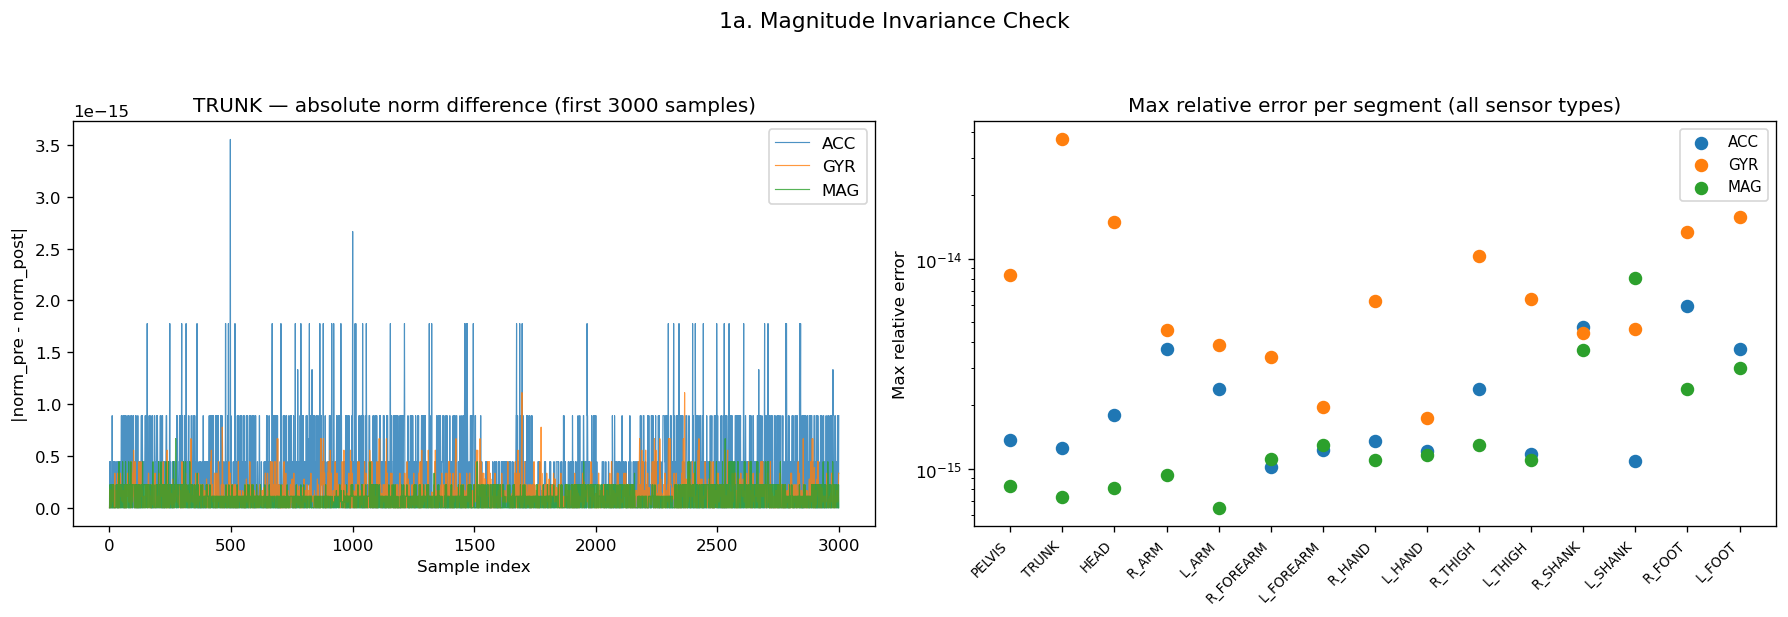

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left: norm time-series for TRUNK
seg_ex = "TRUNK"
colors_s = {"ACC": "#1f77b4", "GYR": "#ff7f0e", "MAG": "#2ca02c"}
for stype in SENSOR_TYPES:
    cols = [f"{seg_ex}_{stype}_{ax}" for ax in AXES]
    if not all(c in pre_df.columns for c in cols):
        continue
    n_pre  = np.linalg.norm(pre_df[cols].values, axis=1)
    n_post = np.linalg.norm(post_df[cols].values, axis=1)
    ax1.plot(np.abs(n_pre - n_post)[:3000], label=stype,
             color=colors_s[stype], alpha=0.8, lw=0.7)

ax1.set_xlabel("Sample index")
ax1.set_ylabel("|norm_pre - norm_post|")
ax1.set_title(f"{seg_ex} — absolute norm difference (first 3000 samples)")
ax1.legend()
ax1.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

# Right: max relative error per segment
for stype in SENSOR_TYPES:
    subset = mag_df[mag_df["sensor"] == stype]
    ax2.scatter(range(len(subset)), subset["max_rel_err"].values,
                label=stype, color=colors_s[stype], s=50, zorder=3)

ax2.set_xticks(range(len(mag_df[mag_df["sensor"] == "ACC"])))
ax2.set_xticklabels(mag_df[mag_df["sensor"] == "ACC"]["segment"],
                     rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Max relative error")
ax2.set_title("Max relative error per segment (all sensor types)")
if mag_df["max_rel_err"].max() > 0:
    ax2.set_yscale("log")
ax2.legend(fontsize=9)

fig.suptitle("1a. Magnitude Invariance Check", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### 1b. Orthonormality Check

Each correction rotation matrix $R$ must satisfy:

$$R^\top R = I \quad \text{and} \quad \det(R) = 1$$

This confirms $R$ is a **proper rotation** — no scaling, skewing, or reflection.

=== Orthonormality Check ===
  segment       det(R)    |det - 1|  max|RTR - I|  PASS
   PELVIS 1.0000000000 4.440892e-16  4.440892e-16  True
    TRUNK 1.0000000000 6.661338e-16  4.440892e-16  True
     HEAD 1.0000000000 2.220446e-16  2.220446e-16  True
    R_ARM 1.0000000000 0.000000e+00  1.110223e-16  True
    L_ARM 1.0000000000 0.000000e+00  2.220446e-16  True
R_FOREARM 1.0000000000 4.440892e-16  4.440892e-16  True
L_FOREARM 1.0000000000 4.440892e-16  4.440892e-16  True
   R_HAND 1.0000000000 3.330669e-16  2.220446e-16  True
   L_HAND 1.0000000000 4.440892e-16  4.440892e-16  True
  R_THIGH 1.0000000000 8.881784e-16  4.440892e-16  True
  L_THIGH 1.0000000000 1.110223e-16  1.110223e-16  True
  R_SHANK 1.0000000000 3.330669e-16  3.330669e-16  True
  L_SHANK 1.0000000000 2.220446e-16  2.220446e-16  True
   R_FOOT 1.0000000000 4.440892e-16  2.220446e-16  True
   L_FOOT 1.0000000000 6.661338e-16  6.661338e-16  True

All PASS: True


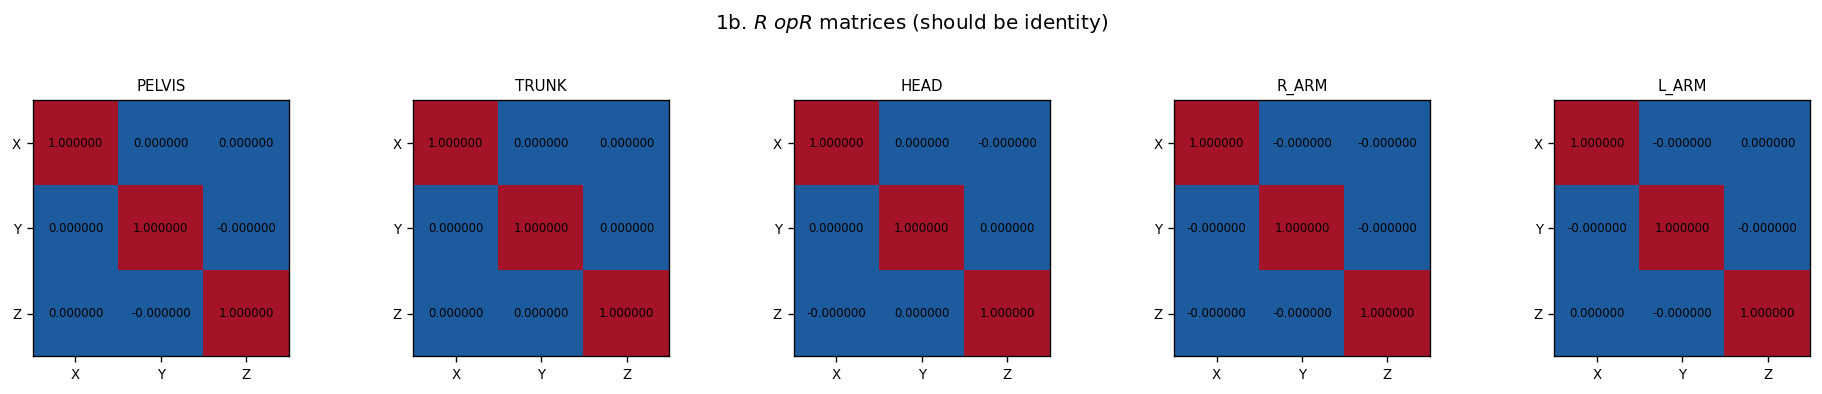

In [6]:
ortho_results = []
for seg, info in corrections.items():
    R_mat = info["R_corr"].as_matrix()
    RTR = R_mat.T @ R_mat
    det = np.linalg.det(R_mat)
    eye_err = np.max(np.abs(RTR - np.eye(3)))
    ortho_results.append({
        "segment": seg,
        "det(R)": f"{det:.10f}",
        "|det - 1|": abs(det - 1),
        "max|RTR - I|": eye_err,
        "PASS": abs(det - 1) < 1e-6 and eye_err < 1e-6,
    })

ortho_df = pd.DataFrame(ortho_results)
print("=== Orthonormality Check ===")
print(ortho_df.to_string(index=False))
print(f"\nAll PASS: {ortho_df['PASS'].all()}")

# Visualize R^T R for selected segments
show_segs = list(corrections.keys())[:5]
fig, axes_arr = plt.subplots(1, len(show_segs), figsize=(3.2 * len(show_segs), 3))
if len(show_segs) == 1:
    axes_arr = [axes_arr]

for ax, seg in zip(axes_arr, show_segs):
    R_mat = corrections[seg]["R_corr"].as_matrix()
    RTR = R_mat.T @ R_mat
    im = ax.imshow(RTR, cmap="RdBu_r", vmin=-0.1, vmax=1.1)
    ax.set_title(seg, fontsize=9)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{RTR[i, j]:.6f}", ha="center", va="center", fontsize=7)
    ax.set_xticks(range(3)); ax.set_xticklabels(AXES, fontsize=8)
    ax.set_yticks(range(3)); ax.set_yticklabels(AXES, fontsize=8)

fig.suptitle(r"1b. $R^	op R$ matrices (should be identity)", fontsize=12, y=1.05)
fig.tight_layout()
plt.show()

---
## 2. Scientific Verification: Physical & Biomechanical Plausibility

Now we verify the axes actually represent the standardized directions.

### 2a. Gravity Alignment (Static Phase)

During quiet standing the **full accelerometer** reading (specific force) equals $+g$ along
the vertical axis and $\approx 0$ on horizontal axes.

NEWBEE's synced ACC uses `sensorFreeAcceleration` (gravity-free), so we perform two checks:

1. **Theoretical gravity direction** — compute $\mathbf{g}_{\text{body}} = R_{\text{corr}} \cdot R_{\text{sensor}\to\text{global}}^{-1} \cdot [0,\; 0,\; 9.81]^\top$
2. **Empirical gravity** — take raw `acceleration_*` (global frame, includes gravity) during the
   static window and transform it to the body frame

**Expected result:**
- Non-foot (Y = up): $\mathbf{g}_{\text{body}} \approx [0,\; 9.81,\; 0]$
- Foot (X = up): $\mathbf{g}_{\text{body}} \approx [9.81,\; 0,\; 0]$

In [7]:
gravity_global = np.array([0.0, 0.0, 9.81])

grav_rows = []
for seg, info in corrections.items():
    R_corr = info["R_corr"]
    R_mean = info["R_mean"]
    xsens_seg = info["xsens_seg"]
    start, end = info["static_window"]

    # --- Theoretical gravity ---
    g_sensor = R_mean.inv().apply(gravity_global)
    g_body_theo = R_corr.apply(g_sensor)

    # --- Empirical gravity (from raw global-frame acceleration) ---
    acc_raw_cols = [f"acceleration_{xsens_seg}_{a}" for a in ("x", "y", "z")]
    if all(c in raw_df.columns for c in acc_raw_cols):
        acc_static = raw_df[acc_raw_cols].values[start:end].mean(axis=0)
        g_sensor_emp = R_mean.inv().apply(acc_static)
        g_body_emp = R_corr.apply(g_sensor_emp)
    else:
        g_body_emp = np.full(3, np.nan)

    is_foot = seg in FOOT_SEGMENTS
    up_idx = 0 if is_foot else 1

    grav_rows.append({
        "segment": seg, "is_foot": is_foot,
        "up_axis": "X" if is_foot else "Y",
        "theo_X": g_body_theo[0], "theo_Y": g_body_theo[1], "theo_Z": g_body_theo[2],
        "emp_X":  g_body_emp[0],  "emp_Y":  g_body_emp[1],  "emp_Z":  g_body_emp[2],
        "theo_up": g_body_theo[up_idx],
        "emp_up":  g_body_emp[up_idx],
    })

grav_df = pd.DataFrame(grav_rows)
print("=== Gravity Alignment (body frame) ===")
print("\nTheoretical gravity direction:")
print(grav_df[["segment", "up_axis", "theo_X", "theo_Y", "theo_Z"]].to_string(
    index=False, float_format=lambda x: f"{x:8.4f}"))
print("\nEmpirical gravity (raw acceleration during static window):")
print(grav_df[["segment", "up_axis", "emp_X", "emp_Y", "emp_Z"]].to_string(
    index=False, float_format=lambda x: f"{x:8.4f}"))
print(f"\nMax theoretical up-axis deviation from 9.81: "
      f"{(grav_df['theo_up'] - 9.81).abs().max():.6f} m/s^2")
print(f"Max empirical up-axis deviation from 9.81:   "
      f"{(grav_df['emp_up'] - 9.81).abs().max():.6f} m/s^2")

=== Gravity Alignment (body frame) ===

Theoretical gravity direction:
  segment up_axis   theo_X   theo_Y   theo_Z
   PELVIS       Y   0.0000   9.8100  -0.0000
    TRUNK       Y   0.0000   9.8100   0.0000
     HEAD       Y   0.0000   9.8100  -0.0000
    R_ARM       Y   0.0000   9.8100  -0.0000
    L_ARM       Y   0.0000   9.8100   0.0000
R_FOREARM       Y  -0.0000   9.8100  -0.0000
L_FOREARM       Y   0.0000   9.8100  -0.0000
   R_HAND       Y   0.0000   9.8100   0.0000
   L_HAND       Y  -0.0000   9.8100  -0.0000
  R_THIGH       Y   0.0000   9.8100   0.0000
  L_THIGH       Y   0.0000   9.8100   0.0000
  R_SHANK       Y   0.0000   9.8100   0.0000
  L_SHANK       Y  -0.0000   9.8100   0.0000
   R_FOOT       X   9.8100   0.0000   0.0000
   L_FOOT       X   9.8100   0.0000  -0.0000

Empirical gravity (raw acceleration during static window):
  segment up_axis    emp_X    emp_Y    emp_Z
   PELVIS       Y  -0.4333  -0.1715  -0.0022
    TRUNK       Y   0.3862  -0.1569   0.1758
     HEAD     

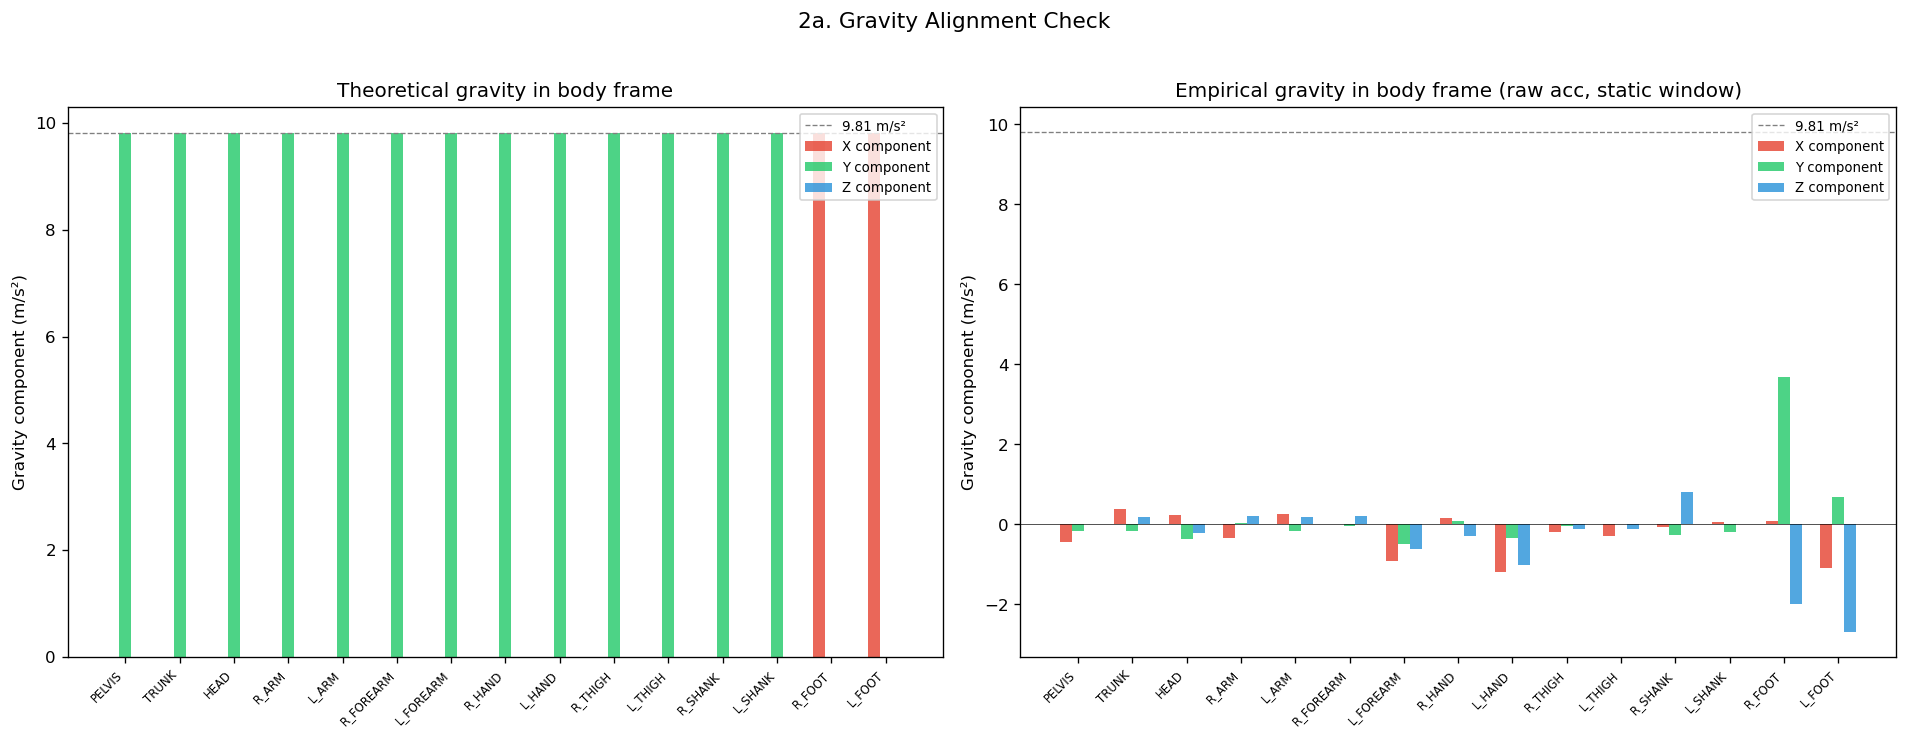

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

segs = grav_df["segment"].values
x = np.arange(len(segs))
w = 0.22

# Left: theoretical gravity components
for i, (axis, color) in enumerate(zip(["theo_X", "theo_Y", "theo_Z"],
                                       ["#e74c3c", "#2ecc71", "#3498db"])):
    ax1.bar(x + (i - 1) * w, grav_df[axis], w, label=f"{'XYZ'[i]} component",
            color=color, alpha=0.85)

ax1.axhline(9.81, color="gray", ls="--", lw=0.8, label="9.81 m/s\u00b2")
ax1.axhline(0, color="black", lw=0.4)
ax1.set_xticks(x); ax1.set_xticklabels(segs, rotation=45, ha="right", fontsize=7)
ax1.set_ylabel("Gravity component (m/s\u00b2)")
ax1.set_title("Theoretical gravity in body frame")
ax1.legend(fontsize=8, loc="upper right")

# Right: empirical gravity components
for i, (axis, color) in enumerate(zip(["emp_X", "emp_Y", "emp_Z"],
                                       ["#e74c3c", "#2ecc71", "#3498db"])):
    ax2.bar(x + (i - 1) * w, grav_df[axis], w, label=f"{'XYZ'[i]} component",
            color=color, alpha=0.85)

ax2.axhline(9.81, color="gray", ls="--", lw=0.8, label="9.81 m/s\u00b2")
ax2.axhline(0, color="black", lw=0.4)
ax2.set_xticks(x); ax2.set_xticklabels(segs, rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("Gravity component (m/s\u00b2)")
ax2.set_title("Empirical gravity in body frame (raw acc, static window)")
ax2.legend(fontsize=8, loc="upper right")

fig.suptitle("2a. Gravity Alignment Check", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### 2b. PCA of Angular Velocity during Gait

During walking, the dominant motion of the shank and thigh is **flexion/extension** in the
sagittal plane. The rotation axis for flexion/extension is the **mediolateral axis**.

In our convention, **Z = right (mediolateral)**. Therefore `GYR_Z` should carry the
**largest variance** for shank and thigh segments during walking.

We verify this with:
1. Per-axis variance ratio of the post-rotation GYR signal
2. PCA — the 1st principal component should be strongly aligned with the Z-axis

In [9]:
pca_segments = ["L_THIGH", "R_THIGH", "L_SHANK", "R_SHANK"]

pca_rows = []
for seg in pca_segments:
    gyr_cols = [f"{seg}_GYR_{ax}" for ax in AXES]
    if not all(c in post_df.columns for c in gyr_cols):
        continue
    gyr = post_df[gyr_cols].values

    var = np.var(gyr, axis=0)
    total_var = var.sum()

    cov = np.cov(gyr.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    pca_rows.append({
        "segment": seg,
        "var_X_pct": var[0] / total_var * 100,
        "var_Y_pct": var[1] / total_var * 100,
        "var_Z_pct": var[2] / total_var * 100,
        "PC1_dir": eigvecs[:, 0],
        "PC1_explained_pct": eigvals[0] / eigvals.sum() * 100,
    })

pca_df = pd.DataFrame(pca_rows)
print("=== GYR Variance Breakdown (%) ===")
print(pca_df[["segment", "var_X_pct", "var_Y_pct", "var_Z_pct",
              "PC1_explained_pct"]].to_string(index=False, float_format=lambda x: f"{x:.1f}"))
print()
for _, row in pca_df.iterrows():
    pc1 = row["PC1_dir"]
    z_pct = row["var_Z_pct"]
    dom = "PASS (Z dominates)" if z_pct > 50 else "WARN (Z does not dominate)"
    print(f"  {row['segment']:10s}  PC1=[{pc1[0]:+.3f}, {pc1[1]:+.3f}, {pc1[2]:+.3f}]  "
          f"Z-var={z_pct:.1f}%  {dom}")

=== GYR Variance Breakdown (%) ===
segment  var_X_pct  var_Y_pct  var_Z_pct  PC1_explained_pct
L_THIGH       21.4       58.8       19.8               62.5
R_THIGH       26.9       45.7       27.5               47.3
L_SHANK       41.1       11.2       47.7               49.8
R_SHANK       46.1       11.7       42.2               51.4

  L_THIGH     PC1=[-0.271, -0.958, -0.091]  Z-var=19.8%  WARN (Z does not dominate)
  R_THIGH     PC1=[-0.186, -0.958, -0.216]  Z-var=27.5%  WARN (Z does not dominate)
  L_SHANK     PC1=[-0.438, -0.082, -0.895]  Z-var=47.7%  WARN (Z does not dominate)
  R_SHANK     PC1=[-0.767, +0.179, -0.617]  Z-var=42.2%  WARN (Z does not dominate)


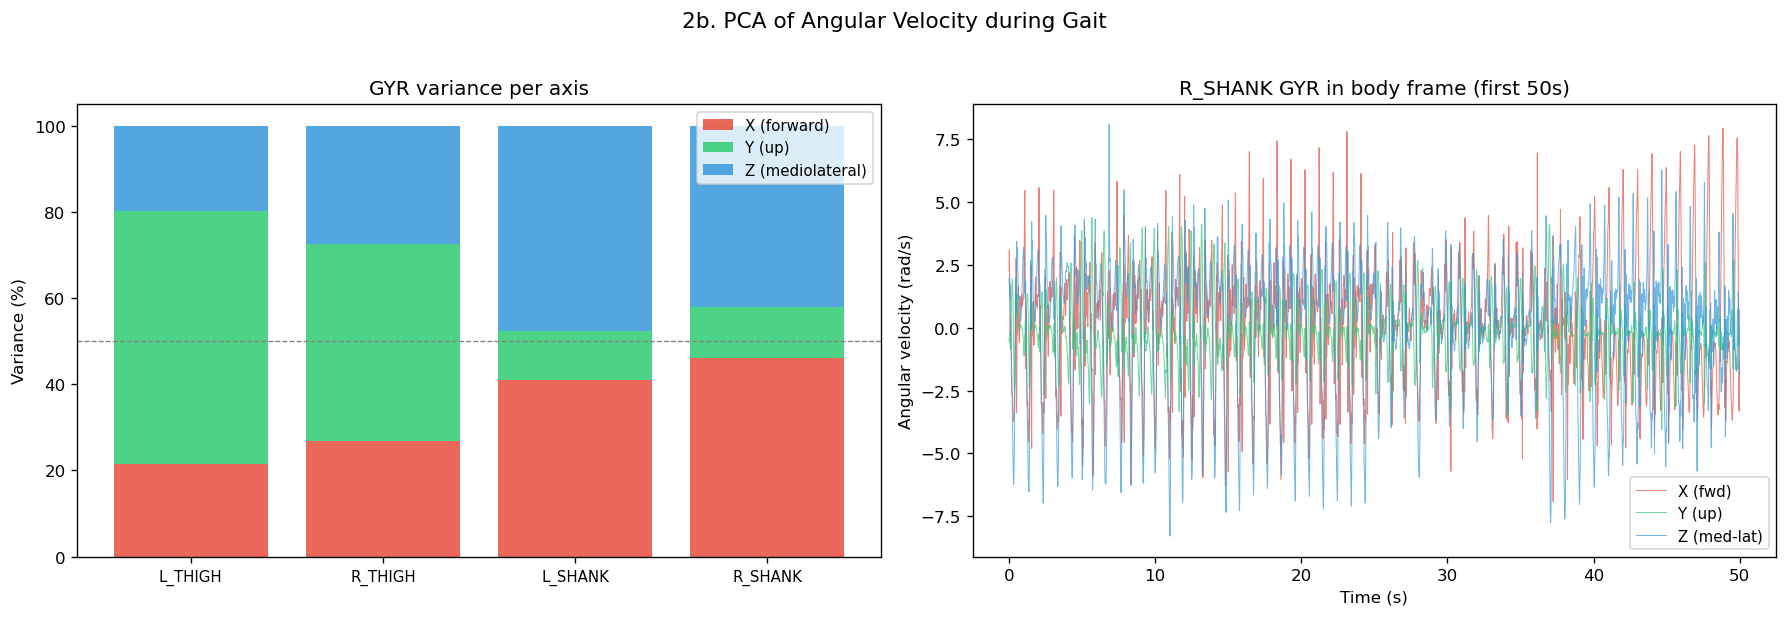

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left: stacked bar of variance per axis
segs_pca = pca_df["segment"].values
x = np.arange(len(segs_pca))
ax1.bar(x, pca_df["var_X_pct"], label="X (forward)", color="#e74c3c", alpha=0.85)
ax1.bar(x, pca_df["var_Y_pct"], bottom=pca_df["var_X_pct"],
        label="Y (up)", color="#2ecc71", alpha=0.85)
ax1.bar(x, pca_df["var_Z_pct"],
        bottom=pca_df["var_X_pct"].values + pca_df["var_Y_pct"].values,
        label="Z (mediolateral)", color="#3498db", alpha=0.85)
ax1.axhline(50, color="gray", ls="--", lw=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(segs_pca, fontsize=9)
ax1.set_ylabel("Variance (%)")
ax1.set_title("GYR variance per axis")
ax1.legend(fontsize=9)
ax1.set_ylim(0, 105)

# Right: GYR time series for R_SHANK
seg_ts = "R_SHANK"
gyr_cols_ts = [f"{seg_ts}_GYR_{ax}" for ax in AXES]
t = np.arange(len(post_df)) / 60.0
colors_ax = ["#e74c3c", "#2ecc71", "#3498db"]
labels_ax = ["X (fwd)", "Y (up)", "Z (med-lat)"]
n_show = min(3000, len(post_df))
for col, c, lab in zip(gyr_cols_ts, colors_ax, labels_ax):
    ax2.plot(t[:n_show], post_df[col].values[:n_show], color=c, alpha=0.7, lw=0.6, label=lab)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Angular velocity (rad/s)")
ax2.set_title(f"{seg_ts} GYR in body frame (first {n_show / 60:.0f}s)")
ax2.legend(fontsize=9)

fig.suptitle("2b. PCA of Angular Velocity during Gait", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 3. Batch Processing

Run all QC checks across **every** NEWBEE file.

The cell below defines `qc_one_file()` and loops over all 60 trials, producing a summary
DataFrame with pass/fail per check per file.

In [11]:
def qc_one_file(pre_path, post_path, raw_path):
    """Run all QC checks on a single file triplet.
    Returns dict of scalar metrics and pass/fail flags."""
    pre  = pd.read_csv(pre_path)
    post = pd.read_csv(post_path)
    raw  = pd.read_csv(raw_path)

    if len(pre) != len(post) or len(pre) != len(raw):
        return {"error": "row count mismatch"}

    heading = derive_forward_from_pelvis(raw)

    max_mag_rel = 0.0
    max_det_err = 0.0
    max_rtr_err = 0.0
    max_grav_up_err = 0.0
    pca_z_ratios = []

    for seg, xsens_seg in SEGMENT_TO_XSENS.items():
        qc = quat_cols(xsens_seg)
        if not all(c in raw.columns for c in qc):
            continue

        rots = load_quaternions(raw, xsens_seg)
        s, e = find_static_window(raw, xsens_seg)
        Rm = mean_quaternion(rots[s:e])
        Rc = compute_correction_with_heading(Rm, seg, heading)
        Rmat = Rc.as_matrix()

        # Orthonormality
        max_det_err = max(max_det_err, abs(np.linalg.det(Rmat) - 1))
        max_rtr_err = max(max_rtr_err, np.max(np.abs(Rmat.T @ Rmat - np.eye(3))))

        # Magnitude invariance
        for stype in SENSOR_TYPES:
            cols = [f"{seg}_{stype}_{ax}" for ax in AXES]
            if not all(c in pre.columns for c in cols):
                continue
            n_pre  = np.linalg.norm(pre[cols].values, axis=1)
            n_post = np.linalg.norm(post[cols].values, axis=1)
            rel = np.max(np.abs(n_pre - n_post) / (n_pre + 1e-12))
            max_mag_rel = max(max_mag_rel, rel)

        # Gravity alignment
        g_body = Rc.apply(Rm.inv().apply([0, 0, 9.81]))
        up_idx = 0 if seg in FOOT_SEGMENTS else 1
        max_grav_up_err = max(max_grav_up_err, abs(g_body[up_idx] - 9.81))

        # PCA (lower-body only)
        if seg in ("L_THIGH", "R_THIGH", "L_SHANK", "R_SHANK"):
            gc = [f"{seg}_GYR_{ax}" for ax in AXES]
            if all(c in post.columns for c in gc):
                v = np.var(post[gc].values, axis=0)
                pca_z_ratios.append(v[2] / v.sum())

    mean_z = float(np.mean(pca_z_ratios)) if pca_z_ratios else np.nan
    return {
        "max_mag_rel_err":   max_mag_rel,
        "max_det_err":       max_det_err,
        "max_rtr_err":       max_rtr_err,
        "max_grav_up_err":   max_grav_up_err,
        "mean_pca_z_ratio":  mean_z,
        "mag_PASS":   max_mag_rel < 1e-6,
        "ortho_PASS": max_det_err < 1e-6 and max_rtr_err < 1e-6,
        "grav_PASS":  max_grav_up_err < 0.1,
        "pca_PASS":   mean_z > 0.5 if not np.isnan(mean_z) else False,
    }


# --- Collect file triplets ---
batch_files = []
for dp, _, fnames in os.walk(NEWBEE_COORDS):
    for fn in sorted(fnames):
        if not fn.endswith(".csv"):
            continue
        post_p = os.path.join(dp, fn)
        rel = os.path.relpath(post_p, NEWBEE_COORDS)
        pre_p = os.path.join(NEWBEE_SYNCED, rel)
        raw_p = os.path.join(NEWBEE_RAW_XSENS, rel)
        if os.path.isfile(pre_p) and os.path.isfile(raw_p):
            batch_files.append({"rel": rel, "pre": pre_p, "post": post_p, "raw": raw_p})

print(f"Files to process: {len(batch_files)}")

# --- Run batch QC ---
results = []
for i, bf in enumerate(batch_files):
    print(f"  [{i+1:3d}/{len(batch_files)}] {bf['rel']}", end="")
    m = qc_one_file(bf["pre"], bf["post"], bf["raw"])
    m["file"] = bf["rel"]
    results.append(m)
    ok = all(m.get(k, False) for k in ("mag_PASS", "ortho_PASS", "grav_PASS"))
    print(f"  {'PASS' if ok else 'FAIL'}")

batch_df = pd.DataFrame(results)

# --- Summary ---
print("\n" + "=" * 60)
print("BATCH QC SUMMARY")
print("=" * 60)
for chk in ("mag_PASS", "ortho_PASS", "grav_PASS", "pca_PASS"):
    n = batch_df[chk].sum()
    print(f"  {chk:15s}: {n}/{len(batch_df)} passed")

failed = batch_df[~(batch_df["mag_PASS"] & batch_df["ortho_PASS"] & batch_df["grav_PASS"])]
if len(failed) == 0:
    print("\n  All files PASSED all checks.")
else:
    print(f"\n  {len(failed)} file(s) FAILED:")
    print(failed[["file", "max_mag_rel_err", "max_det_err", "max_grav_up_err"]].to_string(index=False))

batch_df

Files to process: 60
  [  1/60] courseC/id17/xsens.csv  PASS
  [  2/60] courseC/id10/xsens.csv  PASS
  [  3/60] courseC/id19/xsens.csv  PASS
  [  4/60] courseC/id18/xsens.csv  PASS
  [  5/60] courseC/id16/xsens.csv  PASS
  [  6/60] courseC/id05/xsens.csv  PASS
  [  7/60] courseC/id02/xsens.csv  PASS
  [  8/60] courseC/id03/xsens.csv  PASS
  [  9/60] courseC/id04/xsens.csv  PASS
  [ 10/60] courseC/id13/xsens.csv  PASS
  [ 11/60] courseC/id14/xsens.csv  PASS
  [ 12/60] courseC/id22/xsens.csv  PASS
  [ 13/60] courseC/id25/xsens.csv  PASS
  [ 14/60] courseC/id24/xsens.csv  PASS
  [ 15/60] courseC/id23/xsens.csv  PASS
  [ 16/60] courseC/id15/xsens.csv  PASS
  [ 17/60] courseC/id12/xsens.csv  PASS
  [ 18/60] courseC/id08/xsens.csv  PASS
  [ 19/60] courseC/id01/xsens.csv  PASS
  [ 20/60] courseC/id07/xsens.csv  PASS
  [ 21/60] courseB/id17/xsens.csv  PASS
  [ 22/60] courseB/id10/xsens.csv  PASS
  [ 23/60] courseB/id19/xsens.csv  PASS
  [ 24/60] courseB/id18/xsens.csv  PASS
  [ 25/60] courseB/

KeyError: "None of [Index(['TRUNK_MAG_X', 'TRUNK_MAG_Y', 'TRUNK_MAG_Z'], dtype='object')] are in the [columns]"